In [21]:
import os
from pathlib import Path

inPath = "./demo_data/Bajo/deerYear_2016-2017/Bajo_deerYear_2016-2017.csv"
inCSVname = Path(inPath).stem
deerName=inCSVname.split("_")[0]
deerYear = '_'.join(name for name in  inCSVname.split("_")[1:])
outFolder = os.path.join(Path(inPath).absolute().parent, "OUT_"+deerName+"_"+deerYear)

currPath = Path(os.getcwd())
print(inPath)
print(inCSVname)
print(deerName)
print(deerYear)
print(outFolder)
try:
    os.mkdir(outFolder)
except FileExistsError:
    print("directory exists")
    

./demo_data/Bajo/deerYear_2016-2017/Bajo_deerYear_2016-2017.csv
Bajo_deerYear_2016-2017
Bajo
deerYear_2016-2017
/home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017


### Plot the result of the MigrateR model applied to the red deer trajectory

run the R script

In [ ]:
import subprocess

resultS0 = subprocess.run(
    ["/usr/bin/Rscript" ,
    "./S0_plotMigrateR.R", 
    inPath, 
    outFolder,
    "TRUE"], 
capture_output=True,
text=True)
print(resultS0.stderr)

get the .png output and display it in the notebook

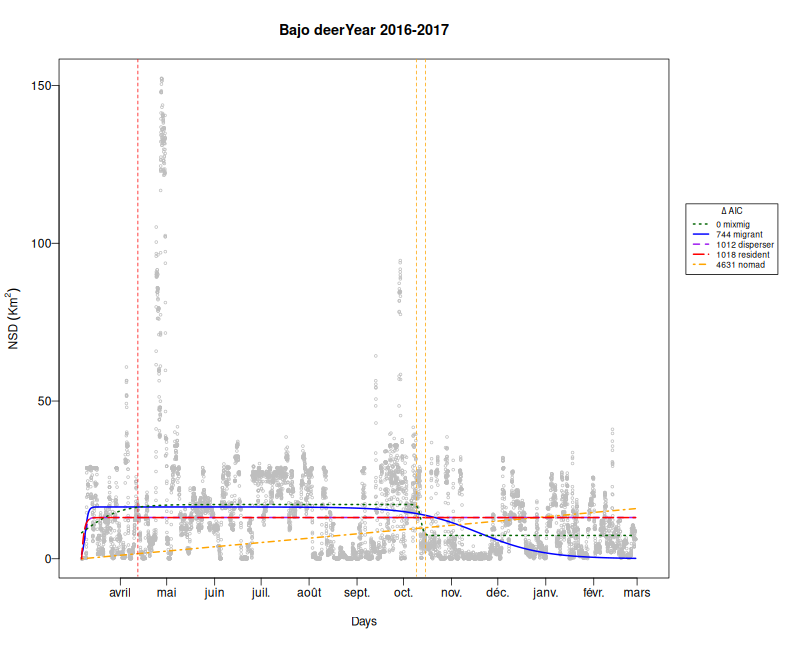

In [23]:
from PIL import Image
img = Image.open(os.path.join(outFolder, "MIGRATE_R PLOT " + ' '.join(inCSVname.split("_")[:])+".png") )
img

Use Trajr package in R To generate a Correlated Random Walk trajectory

In [39]:

resultS1 = subprocess.run(
    ["/usr/bin/Rscript" ,
    "./S1_generate_CRW.R", 
    inPath, 
    outFolder], 
capture_output=True,
text=True)
print(resultS1.stdout)

***** SIMULATE CRW TRAJECTORY ****

 deer Name -->  Bajo , deer Year -->  deerYear_2016-2017 
[1] "mean step length of the whole trajectory : "
[1] 37.36812
[1] "standard deviation step length of the whole trajectory : "
[1] 215.4514
--> CRW trajectory successfuly generated in 
 /home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017/Simulated_CRW_Bajo_deerYear_2016-2017.csv 



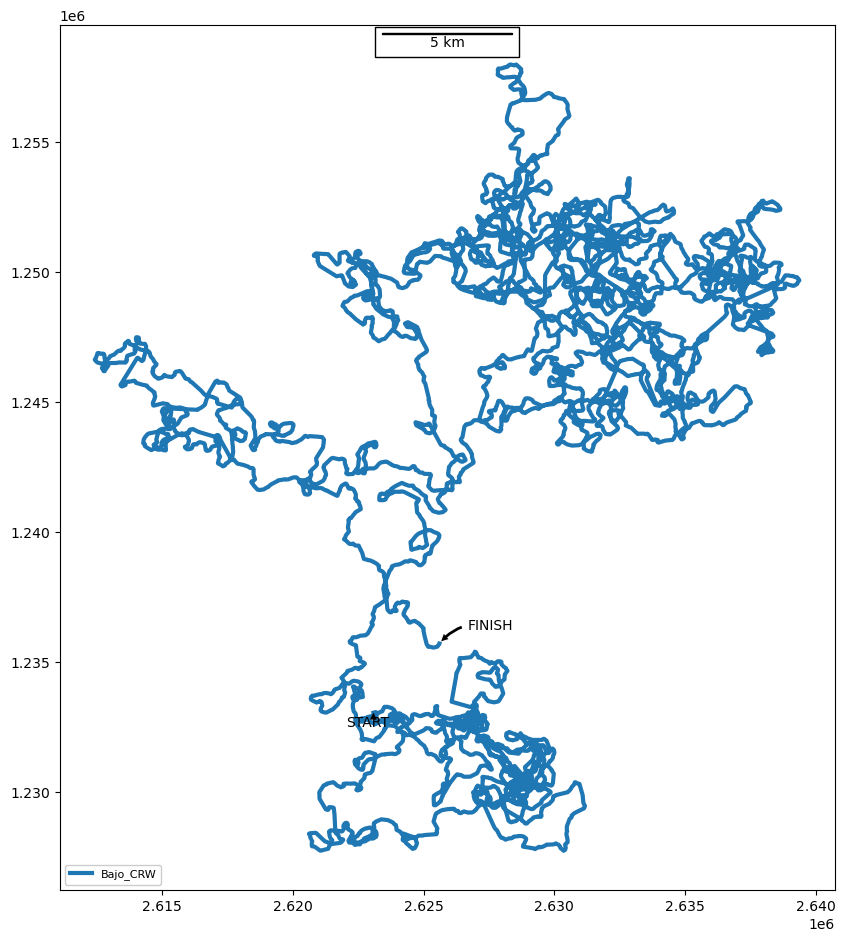

In [41]:
import fractalFunctions
import geopandas as gpd
import pandas as pd

GPSdata = pd.read_csv("/home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017/Simulated_CRW_Bajo_deerYear_2016-2017.csv" )

gpd_sim = gpd.GeoDataFrame(GPSdata, 
geometry = gpd.GeoSeries.from_wkt(GPSdata["geometry"]))
fractalFunctions.showTrajectoryOnMap(gpd_sim, groupBy= "prenom")

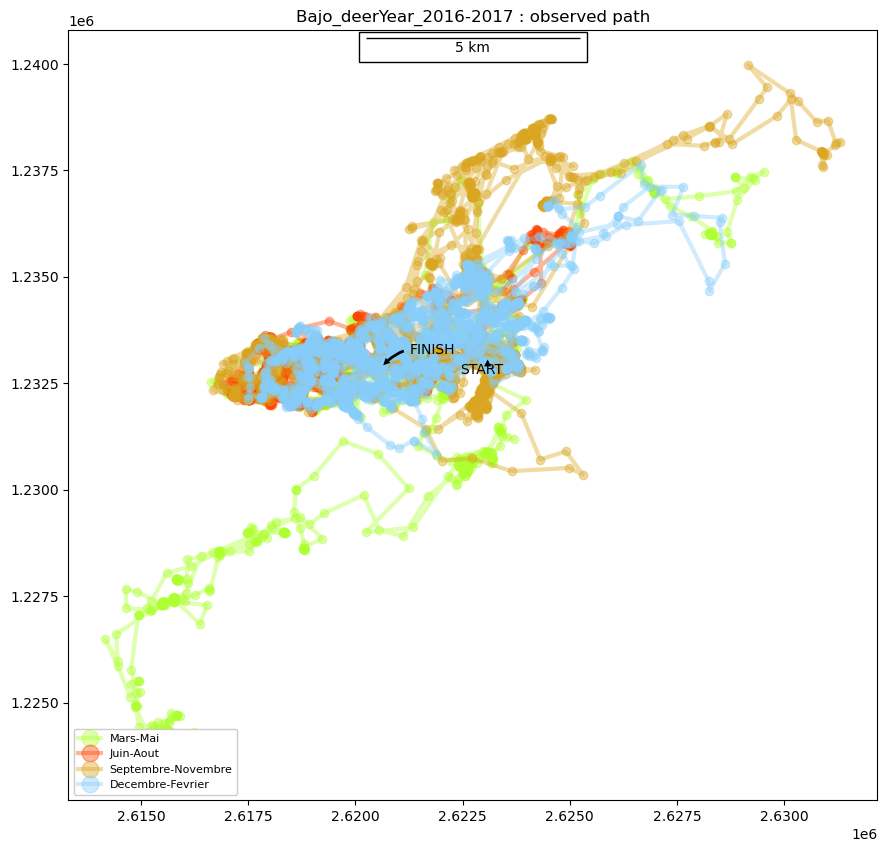

In [43]:
import fractalFunctions
import geopandas as gpd
import pandas as pd

GPSdata = pd.read_csv(inPath)

gpd_obs = gpd.GeoDataFrame(pd.read_csv(inPath), geometry = gpd.GeoSeries.from_wkt(GPSdata["geometry"]))
fractalFunctions.showTrajectoryOnMap(gpd_obs, groupBy= "saison")

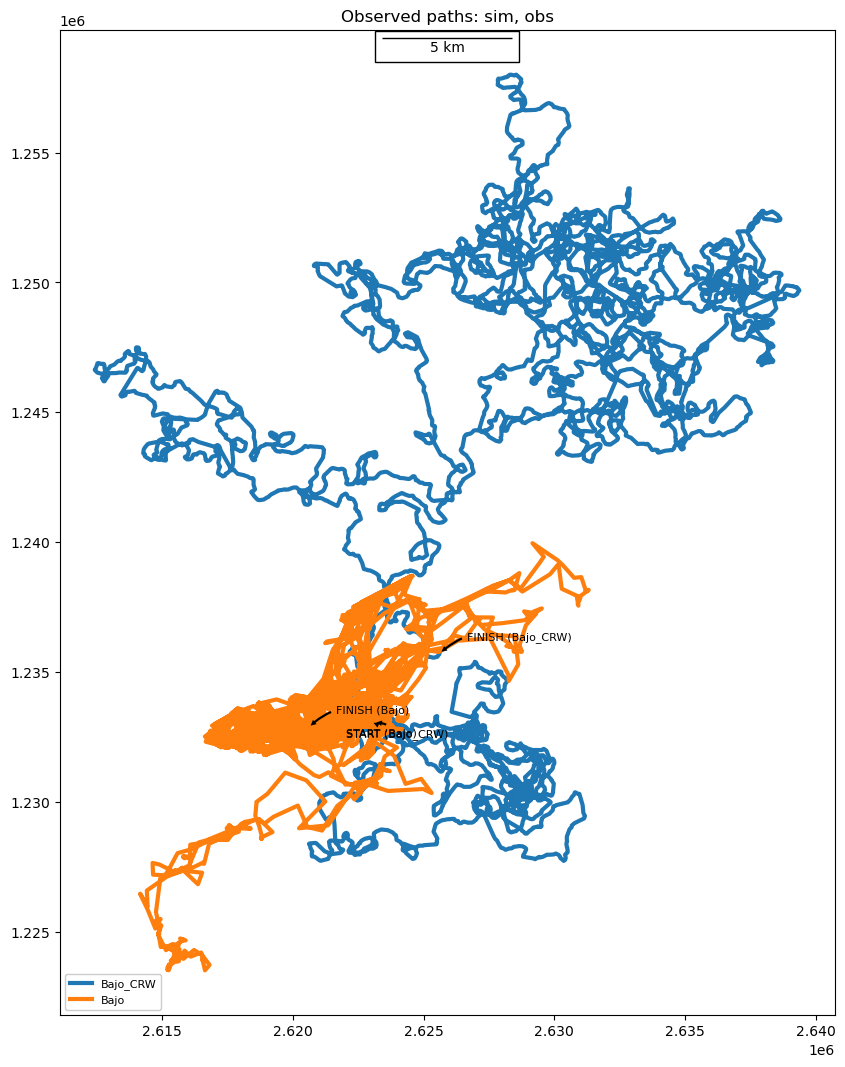

In [50]:

from importlib import reload
reload(fractalFunctions)

fractalFunctions.showMultipleTrajectoriesOnMap([gpd_sim,gpd_obs], groupBy= "prenom", plotNames=["sim", "obs"])

### Le script S2 calcule la valeur de fractalité selon Nams (2003) sur une série de divider dont la longueur est choisie suivant une progression géométrique entre 100m et le tiers de la distance maximale entre deux points de la trajectoire observée

In [ ]:
import sys
sys.argv = ["S2_compute_Fractal_observed_and_simulated_trajectory.py", inPath, outFolder]

with open("./S2_compute_Fractal_observed_and_simulated_trajectory.py") as f:
    exec(f.read())

le script S2 produit la courbe de valeur fractale en fonction du divider length pour la trajectoire simulée et observée

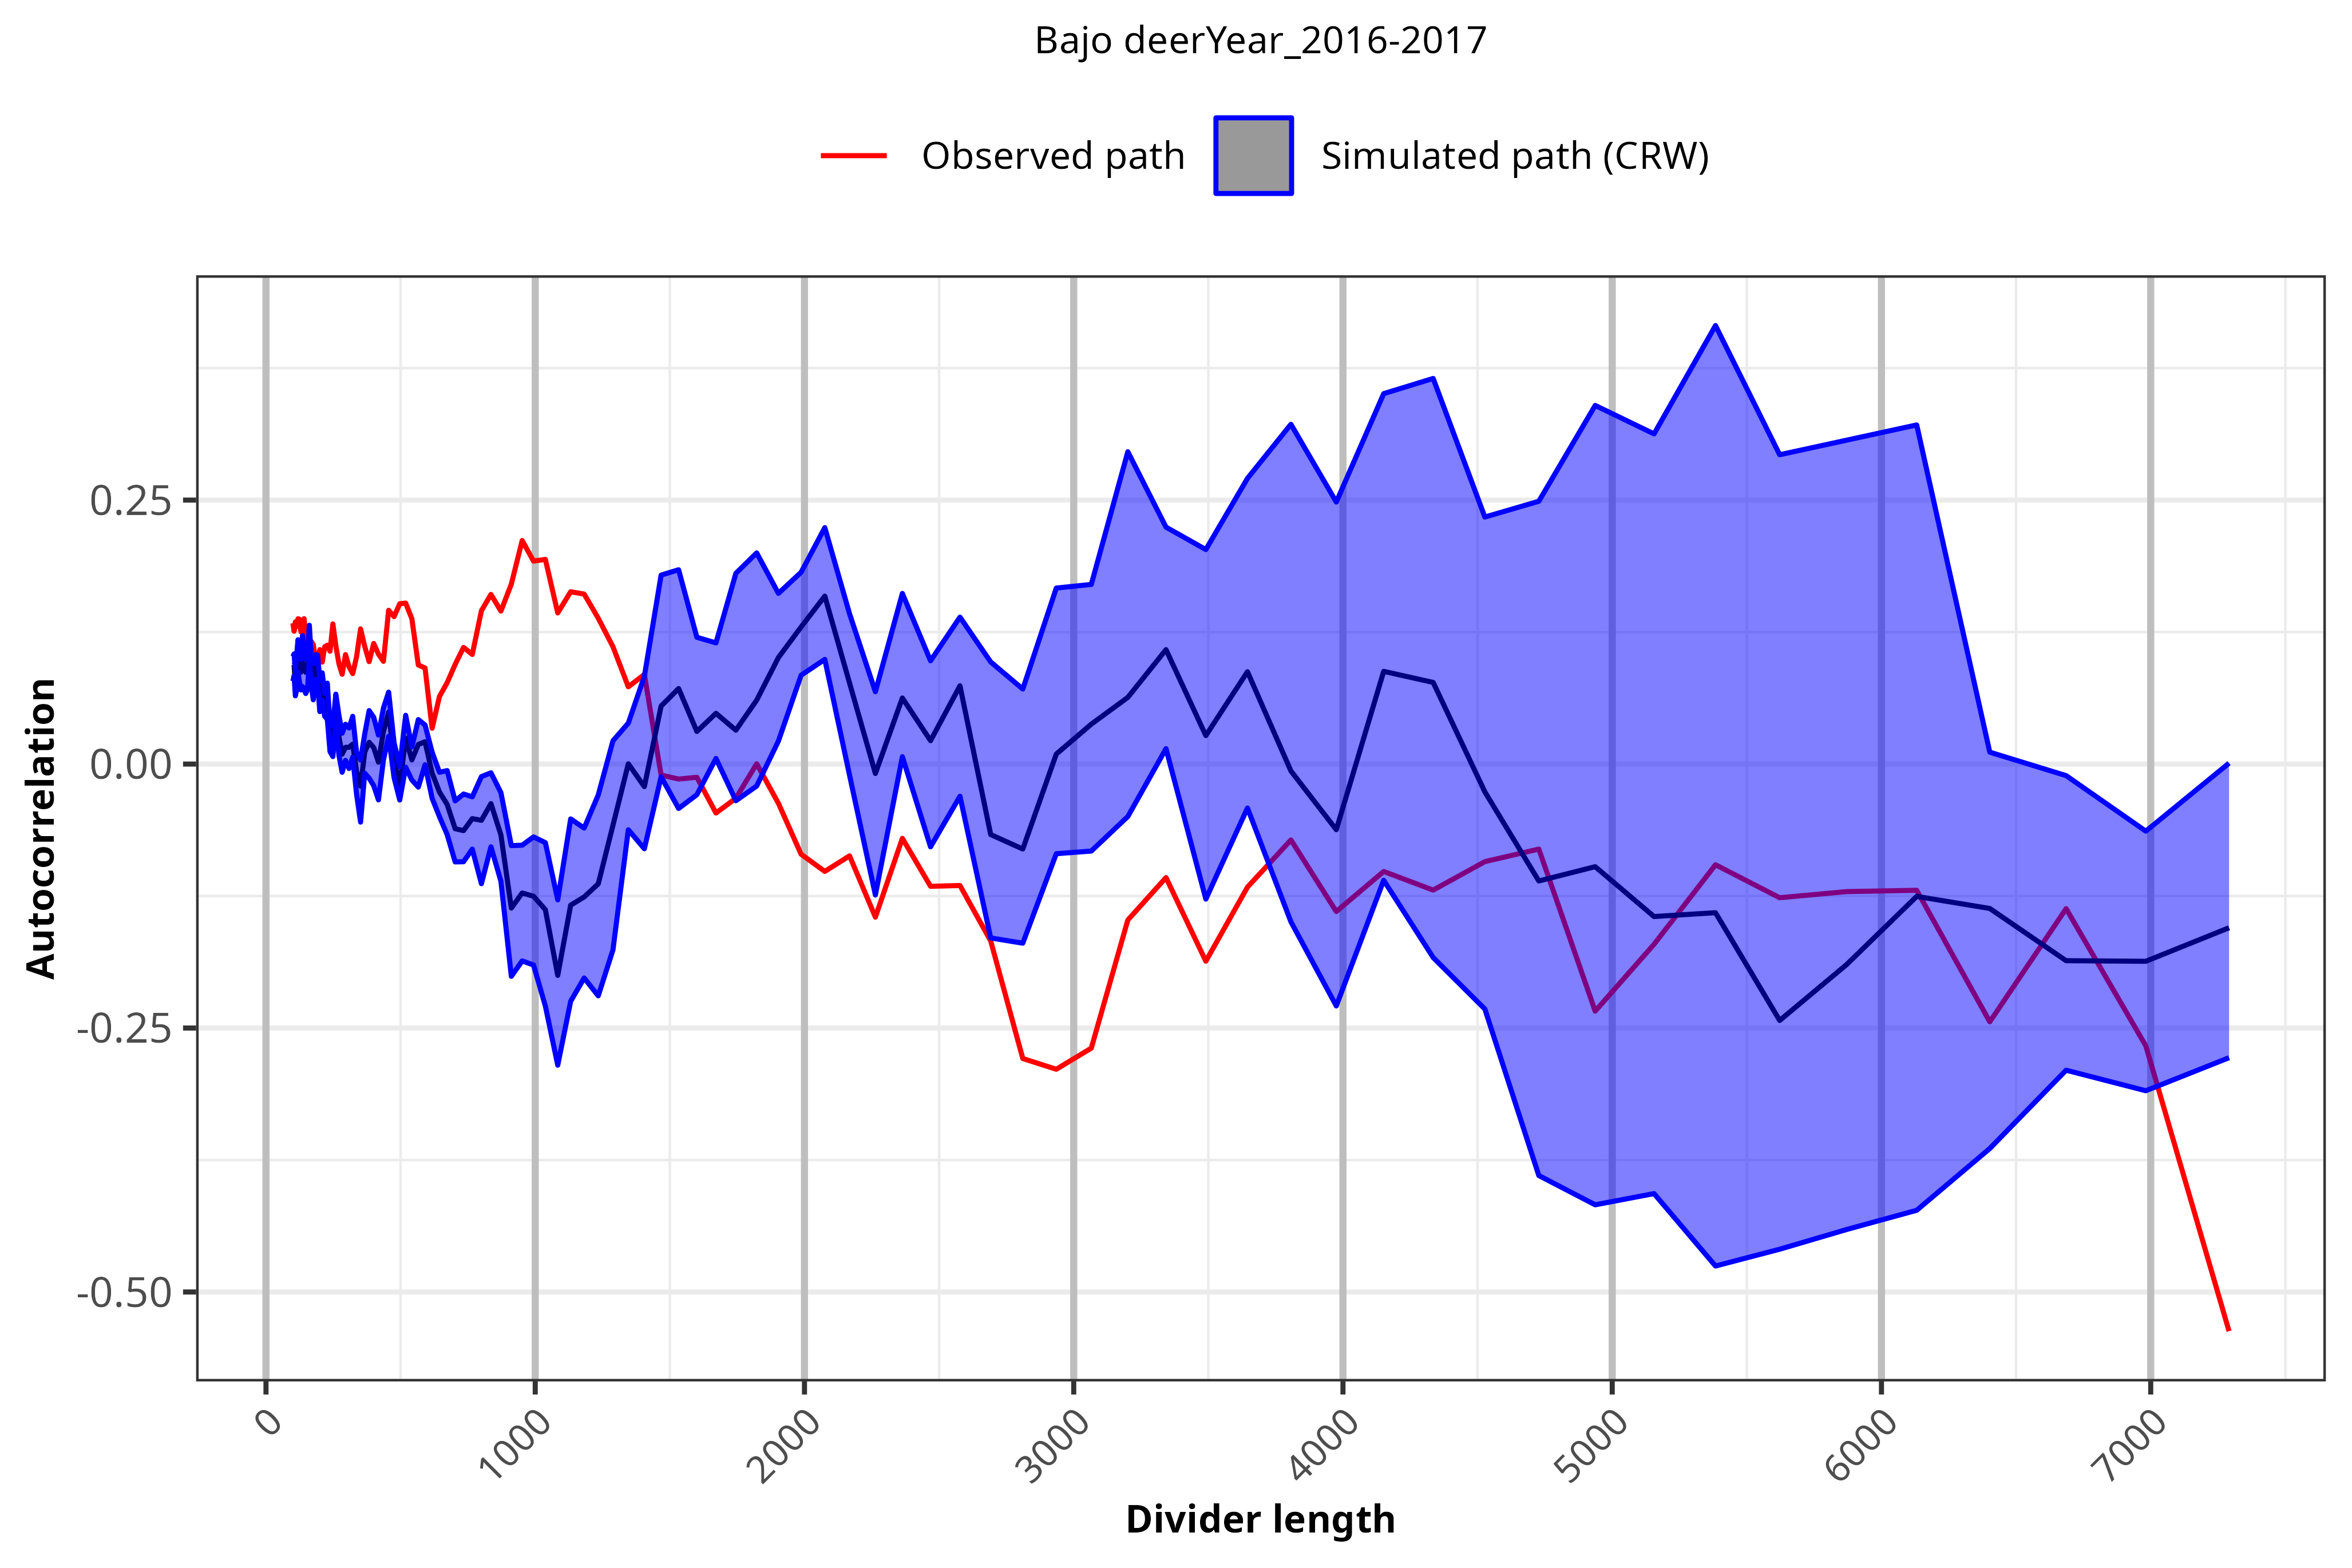

In [88]:
from PIL import Image
img = Image.open("/home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017/Bajo_deerYear_2016-2017_autocorrelation_obs_vs_crw.tiff" )
img

### le script S3 calcule le Z-score entre la trajectoire observée et la trajectoire simulée pour chaque longueur de divider.

In [ ]:

resultS3 = subprocess.run(
    ["/usr/bin/Rscript" ,
    "./S3_get_Zscores_CRW.R", 
    outFolder], 
capture_output=True,
text=True)
print(resultS3.stdout)

###  les divider lenght possédant les plus hautes valeurs de z-scores sont considérées comme des modèles candidats pour la segmentation de la trajectoire en deux comportement. Elle sont stockées dans le fichier "candidate_stepSizes_from_upConf.csv"

In [72]:
candidateDL = os.path.join(outFolder, '_'.join(str for str in [deerName, deerYear, 'candidate_stepSizes_from_upConf.csv']) )

candidateDL_df = pd.read_csv(candidateDL)

candidateDL_df.sort_values(by="zscore",ascending=False).head(10)

,prenom,deerYear,stepSize,obs,zscore
26,Bajo,deerYear_2016-2017,951.554412,0.211705,0.288576
29,Bajo,deerYear_2016-2017,1083.631750,0.143123,0.271755
28,Bajo,deerYear_2016-2017,1037.685361,0.193834,0.268262
27,Bajo,deerYear_2016-2017,993.687116,0.192206,0.261206
25,Bajo,deerYear_2016-2017,911.208151,0.170414,0.247643
31,Bajo,deerYear_2016-2017,1181.717818,0.160981,0.221604
30,Bajo,deerYear_2016-2017,1131.612543,0.163191,0.215141
24,Bajo,deerYear_2016-2017,872.572587,0.144880,0.171941
23,Bajo,deerYear_2016-2017,835.575184,0.160661,0.168933
32,Bajo,deerYear_2016-2017,1234.041642,0.138123,0.167386


### le script S4 tente d'attribuer des classes de comportement ("mouvements dirigés" ou "mouvements tortueux") sur les portions de segments de chaque longueur de divider préalablement sélectionnées. On utilise les variation de turning angle entre deux segments sur toute la trajectoire en appliquant l'algorithme "time-series-k-means" pour détecter les breakpoints. 

In [86]:
%run ./S4_get_behaviour_vector_from_list.py 

usage: S4_get_behaviour_vector_from_list.py [-h] [--check_existing_file]
                                            inFilePath stepListFile
S4_get_behaviour_vector_from_list.py: error: the following arguments are required: inFilePath, stepListFile


SystemExit: 2

### le script S5 estime la qualité de l'attribution des deux classes en calculant divers métriques sur les portions de segments. Trois métriques ont été utilisées : le Net-square dispalcement moyen divisé par le nombre de points observés compris dans la portion de segment("ratoi_meanNSD"), la somme des NSD ("ratio_cumulativeNSD") ainsi que le NSD maximum ("ratio_maxNSD") de ces mêmes portions

In [ ]:

resultS5 = subprocess.run(
    ["/usr/bin/Rscript" ,
    "./S5_choose_best_stepSize_V3.R", 
    outFolder,
    candidateDL], 
capture_output=True,
text=True)
print(resultS5.stdout)

### la valeur de chi-carré des différentes métriques entre les deux classes sont calculées et stockées dans les fichiers "results_chisq_[métrique].csv"

In [92]:
meanNSD = os.path.join(outFolder, '_'.join(str for str in ["results_Chisq_meanNSD",deerName, deerYear, 'from_upConf.csv']) )

meanNSD_df = pd.read_csv(meanNSD)

meanNSD_df.sort_values(by="zscore",ascending=False).head(10)

,prenom,deerYear,stepSize,chisq.raw,chisq.raw.pval,fullPath,parameter,zscore
0,Bajo,deerYear_2016-2017,952,35.317122,2.801582e-09,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.288576
1,Bajo,deerYear_2016-2017,1084,31.884467,1.636203e-08,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.271755
2,Bajo,deerYear_2016-2017,1038,36.483522,1.539623e-09,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.268262
3,Bajo,deerYear_2016-2017,994,45.714513,1.368050e-11,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.261206
4,Bajo,deerYear_2016-2017,911,44.279374,2.847000e-11,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.247643
5,Bajo,deerYear_2016-2017,1182,27.106313,1.925681e-07,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.221604
6,Bajo,deerYear_2016-2017,1132,32.891021,9.747243e-09,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.215141
7,Bajo,deerYear_2016-2017,873,45.887004,1.252740e-11,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.171941
8,Bajo,deerYear_2016-2017,836,60.123765,8.900000e-15,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.168933
9,Bajo,deerYear_2016-2017,1234,20.032997,7.611729e-06,/home/luvil/Workflow_fractalDeer/PIPELINE_FRAC...,meanNSD,0.167386


In [93]:
interstingSegmentation = meanNSD_df.sort_values(by="zscore",ascending=False).loc[0, "fullPath"]

In [94]:
interstingSegmentation

'/home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017/Bajo_deerYear_2016-2017_stepSize_952_autocorrelation_timeSeriesKmeans_2_classes.csv'

In [ ]:
resultS6 = subprocess.run(
    ["/usr/bin/Rscript" ,
    "./S6_2_refine_classification_commandLine.R", 
    interstingSegmentation,
    "ratio_meanNSD"], 
capture_output=True,
text=True)
print(resultS6.stdout)

In [103]:
meanNSD_df.sort_values(by="zscore",ascending=False).loc[1:10, "stepSize"].to_list()

[1084, 1038, 994, 911, 1182, 1132, 873, 836, 1234, 800]

In [117]:
import ipywidgets as ipw

def plotBehaviourNSD(stepSizeSelection, metric):
    segmentationFile = meanNSD_df.loc[meanNSD_df["stepSize"]==stepSizeSelection, "fullPath"].to_list()[0]
    results = subprocess.call(
        ["/usr/bin/Rscript" ,
        "./S6_3_refine_classification_interactive.R", 
        segmentationFile,
        metric], 
        )  
    img = Image.open(os.path.join(outFolder, "tmp_S6_3.png" ))
    display(img)
    
###################### GUI interactive function #####################################

x = meanNSD_df.sort_values(by="zscore",ascending=False).loc[1:10, "stepSize"].to_list()
     
style = {'description_width': '150px'}
layout={"width":"800px"}
menu=ipw.interactive(
     plotBehaviourNSD,{"manual":True},
stepSizeSelection = ipw.SelectionSlider(options=x, value=x[0], description="choose",style=style),
metric=ipw.Dropdown(options=["ratio_meanNSD","ratio_endNSD","ratio_cumulativeNSD"], 
                                   value="ratio_meanNSD", description="metric to use", disabled=False),

)

box=ipw.VBox(
[ ipw.HBox(menu.children) ] ,
layout=ipw.Layout(width='100px', display="flex"))

display(menu)
#######################################################################################

interactive(children=(SelectionSlider(description='choose', options=(1084, 1038, 994, 911, 1182, 1132, 873, 83…

In [ ]:
from PIL import Image
img = Image.open("//home/luvil/Workflow_fractalDeer/PIPELINE_FRACTALDEER/demo_data/Bajo/deerYear_2016-2017/OUT_Bajo_deerYear_2016-2017/NSD WITH BEHAVIOUR Bajo deerYear 2016-2017 stepSize 952 autocorrelation timeSeriesKmeans 2 classes REFINED RATIO MEANNSD.png" )
img